# Análise de Top Performers
### Olist · Tech Challenge Fase 1 (POSTECH DTAT) · Trilha 1 / Trilha 5

**Pergunta de negócio:** _Quem são os protagonistas do marketplace — produtos e sellers — e quais a Olist deve proteger, acelerar ou monitorar?_

Cobre:
1. Ranking de **produtos** top performers (receita, volume, ticket)
2. Ranking de **sellers** top performers
3. **Concentração** de receita por seller (Pareto)
4. **Qualidade × escala** dos sellers (review, lead time)
5. Matriz de **priorização** de sellers (receita × satisfação × velocidade)
6. **Insights** e **recomendações** estratégicas

## 0. Setup, carga e escopo

Bloco reprodutível idêntico em todos os notebooks: carrega os 9 datasets do Olist, define o **escopo canônico — apenas pedidos entregues (`delivered`)** — e enriquece a tabela de itens com categoria traduzida e UF de cliente/seller. Os pedidos **não entregues** são tratados no adendo e excluídos da análise.

> **Convenção de métricas:** _ticket médio_ = valor da **mercadoria** (`price`, sem frete); _receita/faturamento_ = `price + frete` (GMV); _frete %_ = mediana do `frete/price` **por pedido**.



In [1]:
# === Setup: imports e tema visual ===
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Localiza a raiz do projeto (onde existe a pasta data/)
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / "data" / "olist_orders_dataset.csv").exists():
        ROOT = cand; break
DATA_DIR = ROOT / "data"
FIG_DIR  = ROOT / "figs";    FIG_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR  = ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 100, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
# Paleta Darwin / Olist
ROSA, PRETO, TEAL, AMARELO, AZUL, CINZA = "#de0078","#1f1f1f","#00a3a1","#ffb800","#5b6bf5","#8c8c8c"
PALETTE = [ROSA, TEAL, AMARELO, AZUL, CINZA, PRETO]

def brl(x, _=None):
    return f"R$ {x:,.0f}".replace(",", ".")
print("Projeto:", ROOT)

Projeto: C:\Users\vitor\tc_olist


In [2]:
# === Carga dos 9 datasets do Olist ===
def load(name):
    df = pd.read_csv(DATA_DIR / name)
    return df

orders    = load("olist_orders_dataset.csv")
items     = load("olist_order_items_dataset.csv")
payments  = load("olist_order_payments_dataset.csv")
reviews   = load("olist_order_reviews_dataset.csv")
products  = load("olist_products_dataset.csv")
customers = load("olist_customers_dataset.csv")
sellers   = load("olist_sellers_dataset.csv")
cat_trans = load("product_category_name_translation.csv")

ts_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
           "order_delivered_customer_date","order_estimated_delivery_date"]
for c in ts_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print(f"orders={orders.shape} | items={items.shape} | payments={payments.shape} | reviews={reviews.shape}")
print(f"Janela de compra: {orders['order_purchase_timestamp'].min().date()} -> {orders['order_purchase_timestamp'].max().date()}")

orders=(99441, 8) | items=(112650, 7) | payments=(103886, 5) | reviews=(99224, 7)
Janela de compra: 2016-09-04 -> 2018-10-17


In [3]:
# === Escopo canonico: APENAS pedidos ENTREGUES (delivered) ===
# Decisao de escopo: usamos somente pedidos efetivamente entregues. Os casos nao
# entregues (shipped/invoiced/processing/canceled/unavailable/...) sao mostrados
# separadamente no ADENDO e excluidos da analise -- so os entregues tem data de
# entrega, frete realizado e review confiaveis.
ESCOPO_STATUS = "delivered"
orders_v = orders[orders["order_status"] == ESCOPO_STATUS].copy()
orders_v["year_month"] = orders_v["order_purchase_timestamp"].dt.to_period("M")

# Convencao do projeto (duas metricas distintas, NAO confundir):
#  - gross_price   = valor da MERCADORIA do pedido (soma dos precos dos itens)  -> base do TICKET MEDIO
#  - order_revenue = gross_price + frete (GMV recebido pela plataforma)         -> base da RECEITA/FATURAMENTO
# Ticket medio considera APENAS o produto (sem frete). Frete entra so como variavel propria.
items_rev = (items.groupby("order_id")
                  .agg(gross_price=("price","sum"),
                       freight=("freight_value","sum"),
                       n_items=("order_item_id","count"))
                  .reset_index())
items_rev["order_revenue"] = items_rev["gross_price"] + items_rev["freight"]

orders_v = orders_v.merge(items_rev, on="order_id", how="left")
orders_v = orders_v.merge(
    customers[["customer_id","customer_unique_id","customer_state","customer_city"]],
    on="customer_id", how="left")
orders_v["lead_time_dias"] = (orders_v["order_delivered_customer_date"]
                              - orders_v["order_purchase_timestamp"]).dt.days
# Frete como % do preco, calculado POR PEDIDO (a mediana disso = frete do pedido tipico)
orders_v["frete_pct_pedido"] = orders_v["freight"] / orders_v["gross_price"].replace(0, np.nan)

# Tabela de itens enriquecida (categoria PT->EN, UF cliente, UF seller)
items_full = (items.merge(products[["product_id","product_category_name"]], on="product_id", how="left")
                   .merge(cat_trans, on="product_category_name", how="left")
                   .merge(orders_v[["order_id","year_month","customer_state","customer_city"]], on="order_id", how="inner")
                   .merge(sellers[["seller_id","seller_state","seller_city"]], on="seller_id", how="left"))
items_full["revenue"] = items_full["price"] + items_full["freight_value"]
items_full["cat"] = (items_full["product_category_name_english"]
                     .fillna("sem_categoria").str.replace("_"," ").str.title())

print(f"Escopo: APENAS pedidos entregues (delivered)")
print(f"Pedidos entregues: {orders_v['order_id'].nunique():,}")
print(f"Clientes unicos:   {orders_v['customer_unique_id'].nunique():,}")
print(f"Receita total (GMV c/ frete): R$ {orders_v['order_revenue'].sum():,.2f}")
print(f"Ticket medio (mercadoria):    R$ {orders_v['gross_price'].mean():,.2f}")
print(f"Frete % do preco (mediana por pedido): {orders_v['frete_pct_pedido'].median():.1%}")

Escopo: APENAS pedidos entregues (delivered)
Pedidos entregues: 96,478
Clientes unicos:   93,358
Receita total (GMV c/ frete): R$ 15,419,773.75
Ticket medio (mercadoria):    R$ 137.04
Frete % do preco (mediana por pedido): 22.4%


## 1. Top produtos por receita

O dataset não traz nome de produto (apenas `product_id` e categoria). Identificamos os produtos campeões
por `product_id` e os rotulamos pela categoria + sufixo do id.

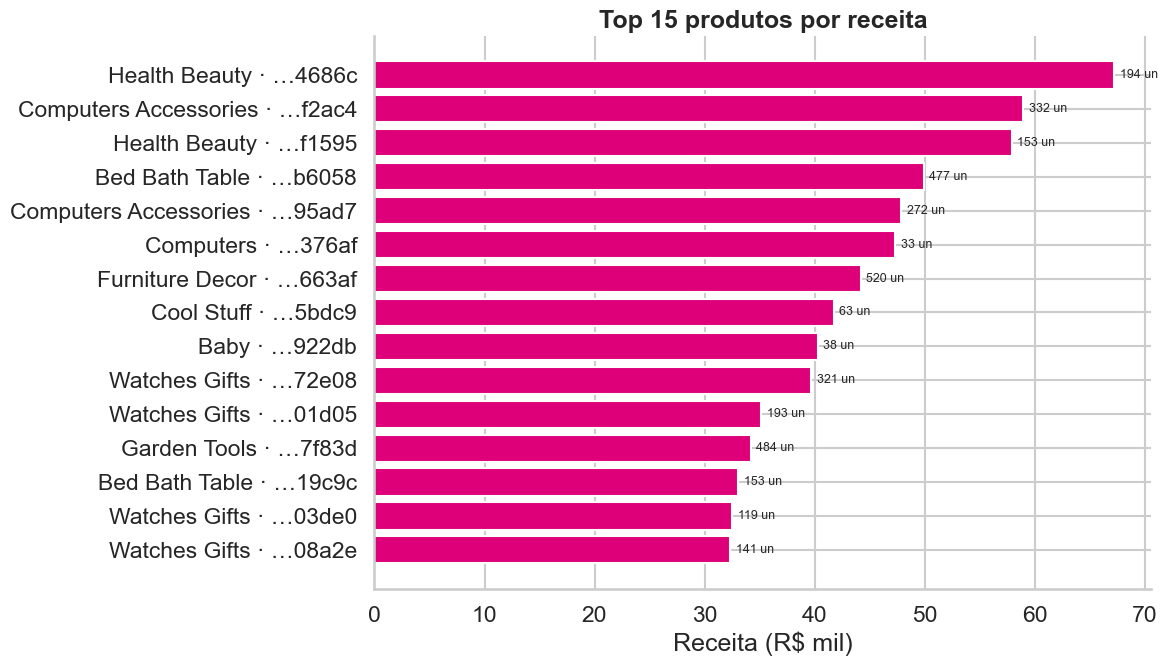

Top 20 produtos = 5.2% da receita | total de produtos vendidos: 32,216
Categoria mais frequente no top 50 produtos: Watches Gifts


In [4]:
prod = (items_full.groupby(["product_id","cat"])
                  .agg(receita=("revenue","sum"),
                       itens=("order_item_id","count"),
                       pedidos=("order_id","nunique"),
                       preco_medio=("price","mean"))
                  .reset_index().sort_values("receita", ascending=False))
prod["share"] = prod["receita"]/prod["receita"].sum()
prod["label"] = prod["cat"]+" · …"+prod["product_id"].str[-5:]
top_prod = prod.head(15)

fig, ax = plt.subplots(figsize=(12,7))
ax.barh(top_prod["label"][::-1], (top_prod["receita"]/1e3)[::-1], color=ROSA)
ax.set_xlabel("Receita (R$ mil)"); ax.set_title("Top 15 produtos por receita")
for i,v in enumerate((top_prod["itens"])[::-1]):
    ax.text((top_prod["receita"]/1e3)[::-1].iloc[i]+0.5, i, f"{v:.0f} un", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR/"p3_01_top_produtos.png"); plt.show()
print(f"Top 20 produtos = {prod.head(20)['share'].sum():.1%} da receita | total de produtos vendidos: {prod.shape[0]:,}")
print(f"Categoria mais frequente no top 50 produtos: {prod.head(50)['cat'].mode().iloc[0]}")

## 2. Top sellers por receita

Sellers são os clientes diretos da Olist (é um marketplace B2B2C). Quem fatura mais é quem a plataforma
mais precisa reter.

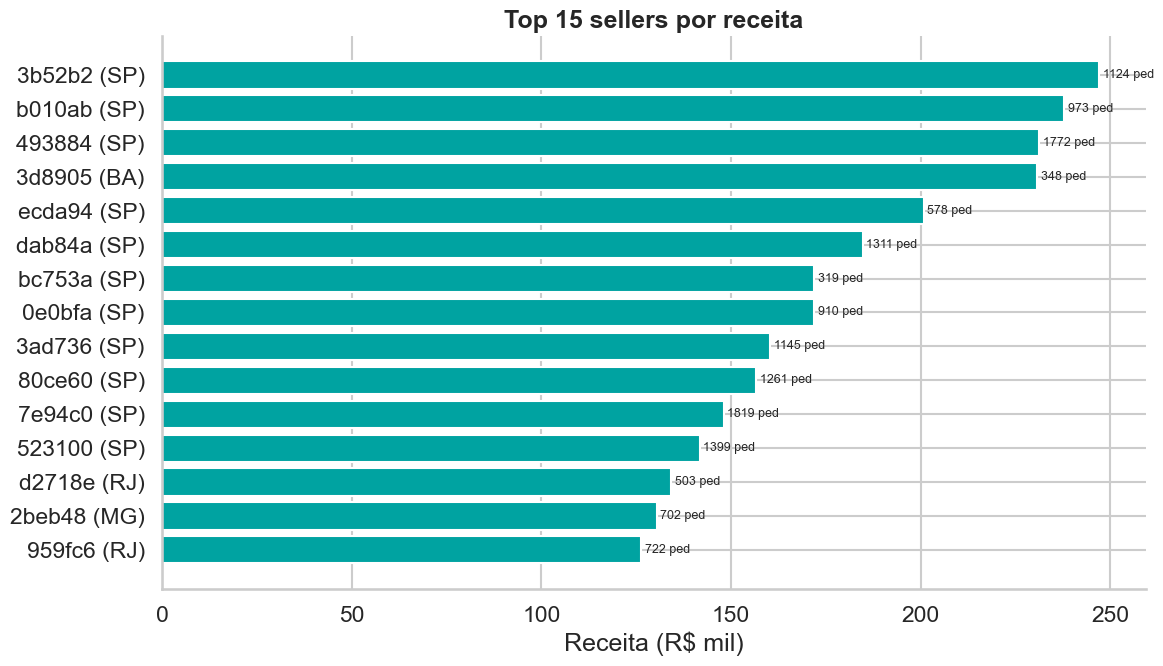

Total sellers ativos: 2,970 | UF dominante no top 20: SP


In [5]:
sel = (items_full.groupby(["seller_id","seller_state"])
                 .agg(receita=("revenue","sum"),
                      produto=("price","sum"),
                      pedidos=("order_id","nunique"),
                      itens=("order_item_id","count"),
                      categorias=("cat","nunique"))
                 .reset_index().sort_values("receita", ascending=False))
sel["share"] = sel["receita"]/sel["receita"].sum()
sel["cum_share"] = sel["share"].cumsum()
sel["ticket"] = sel["produto"]/sel["pedidos"]   # ticket = mercadoria (sem frete)
sel["label"] = sel["seller_id"].str[-6:]+" ("+sel["seller_state"]+")"
top_sel = sel.head(15)

fig, ax = plt.subplots(figsize=(12,7))
ax.barh(top_sel["label"][::-1], (top_sel["receita"]/1e3)[::-1], color=TEAL)
ax.set_xlabel("Receita (R$ mil)"); ax.set_title("Top 15 sellers por receita")
for i,v in enumerate((top_sel["pedidos"])[::-1]):
    ax.text((top_sel["receita"]/1e3)[::-1].iloc[i]+1, i, f"{v:.0f} ped", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR/"p3_02_top_sellers.png"); plt.show()
print(f"Total sellers ativos: {sel.shape[0]:,} | UF dominante no top 20: {sel.head(20)['seller_state'].mode().iloc[0]}")

## 3. Concentração de receita por seller (Pareto)

Quantos sellers sustentam 80% da receita? Define o tamanho do grupo "estratégico" que merece gestão de conta dedicada.

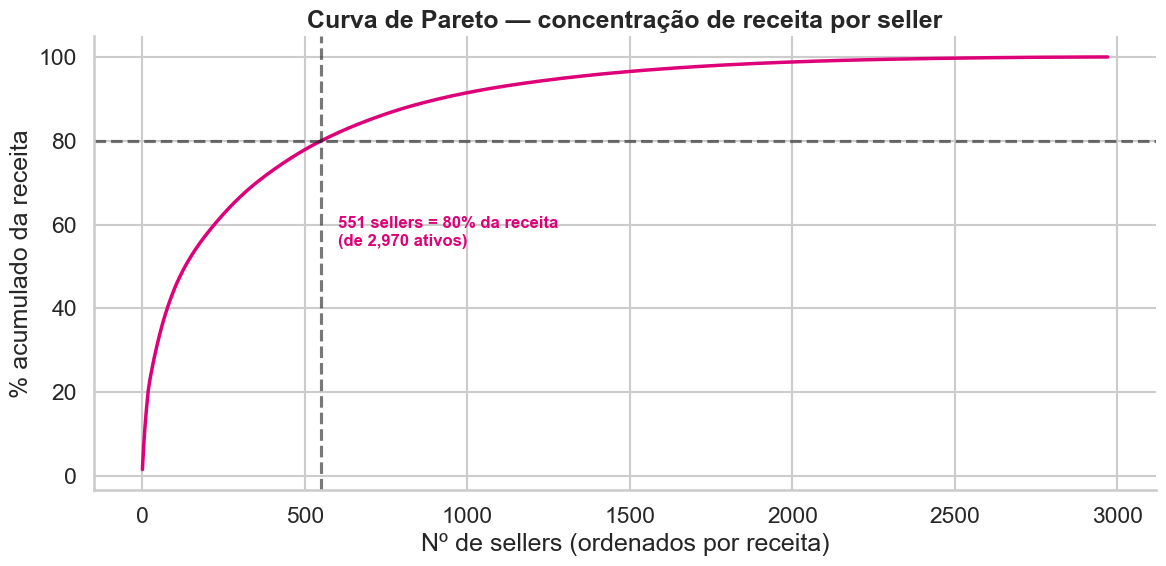

Top20 sellers = 21.0% | Top100 = 44.8% | 80% em 551 sellers (18.6% da base)


In [6]:
n80 = int((sel["cum_share"]<0.8).sum()+1)
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(1,len(sel)+1), sel["cum_share"]*100, color=ROSA, lw=2.5)
ax.axhline(80, color=PRETO, ls="--", alpha=.6); ax.axvline(n80, color=PRETO, ls="--", alpha=.6)
ax.annotate(f"{n80} sellers = 80% da receita\n(de {len(sel):,} ativos)", (n80+50, 55),
            fontsize=12, color=ROSA, weight="bold")
ax.set_xlabel("Nº de sellers (ordenados por receita)"); ax.set_ylabel("% acumulado da receita")
ax.set_title("Curva de Pareto — concentração de receita por seller")
plt.tight_layout(); plt.savefig(FIG_DIR/"p3_03_pareto_sellers.png"); plt.show()
print(f"Top20 sellers = {sel.head(20)['share'].sum():.1%} | Top100 = {sel.head(100)['share'].sum():.1%} | 80% em {n80} sellers ({n80/len(sel):.1%} da base)")

## 4. Qualidade × escala dos sellers

Para sellers com volume relevante (≥ 50 pedidos), cruzamos **satisfação** (% de reviews ≥ 4, um proxy de NPS)
com **velocidade** (lead time médio de entrega) e tamanho de receita. Mostra que faturar alto não garante
qualidade — e isso é um risco.

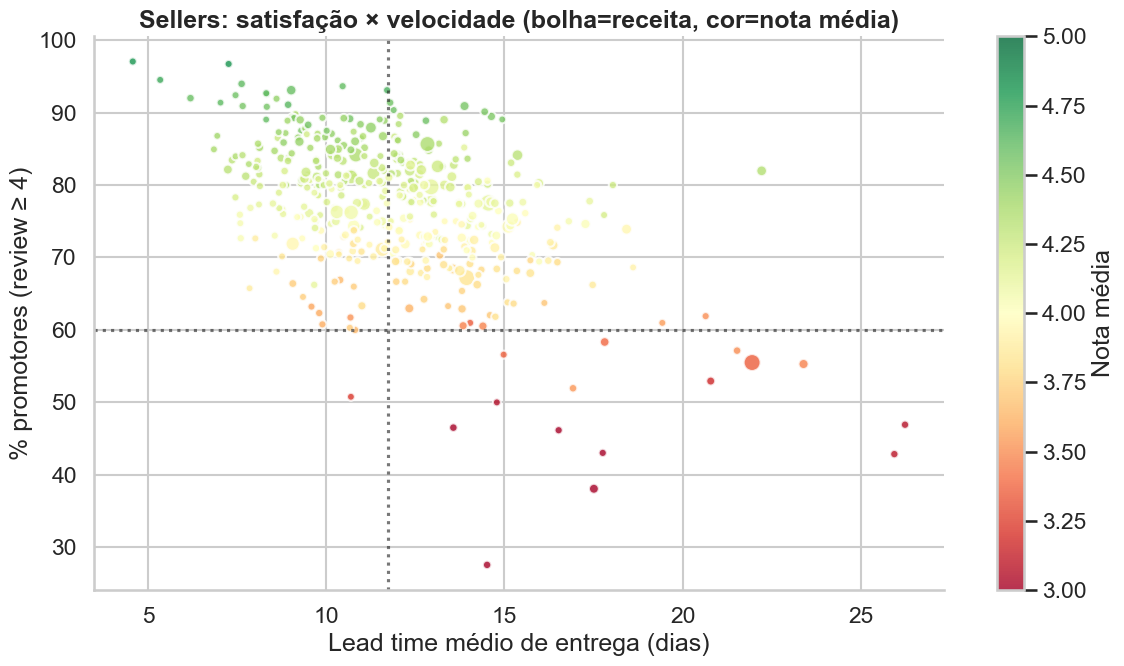

Sellers de receita alta MAS com NPS-proxy < 60%: 9 (risco operacional)


In [7]:
rev = reviews[["order_id","review_score"]].drop_duplicates("order_id")
sk = (items_full.merge(rev, on="order_id", how="left")
                .merge(orders_v[["order_id","lead_time_dias"]], on="order_id", how="left")
                .groupby("seller_id")
                .agg(receita=("revenue","sum"), pedidos=("order_id","nunique"),
                     review_medio=("review_score","mean"),
                     lead_time=("lead_time_dias","mean"),
                     pct_prom=("review_score", lambda s:(s>=4).mean()))
                .reset_index())
elig = sk[sk["pedidos"]>=50].copy()
elig["nps_proxy"] = elig["pct_prom"]*100
fig, ax = plt.subplots(figsize=(12,7))
sc = ax.scatter(elig["lead_time"], elig["nps_proxy"], s=elig["receita"]/2e3+30,
                c=elig["review_medio"], cmap="RdYlGn", vmin=3, vmax=5, alpha=.8, edgecolor="white")
ax.axhline(60, color=PRETO, ls=":", alpha=.6); ax.axvline(elig["lead_time"].median(), color=PRETO, ls=":", alpha=.6)
ax.set_xlabel("Lead time médio de entrega (dias)"); ax.set_ylabel("% promotores (review ≥ 4)")
ax.set_title("Sellers: satisfação × velocidade (bolha=receita, cor=nota média)")
plt.colorbar(sc, label="Nota média")
plt.tight_layout(); plt.savefig(FIG_DIR/"p3_04_qualidade_escala.png"); plt.show()
risco = elig[(elig["nps_proxy"]<60) & (elig["receita"]>elig["receita"].median())]
print(f"Sellers de receita alta MAS com NPS-proxy < 60%: {len(risco)} (risco operacional)")

## 5. Matriz de priorização de sellers

Score composto (0–1) combinando **receita (50%)**, **satisfação (30%)** e **velocidade (20%)** para ranquear
quem a Olist deve priorizar em gestão de conta e programa de aceleração.

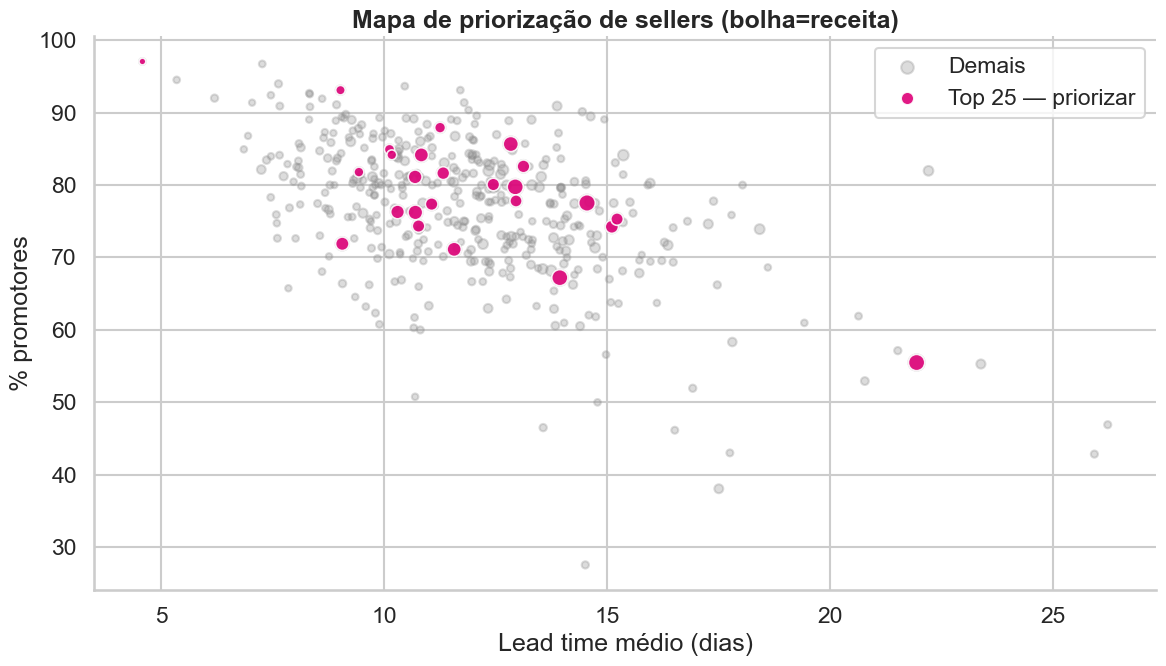

Top 5 sellers a priorizar:
                       seller_id   receita  nps_proxy  lead_time  priority
4869f7a5dfa277a7dca6462dcf3b52b2 247007.06      77.53      14.55      0.82
53243585a1d6dc2643021fd1853d8905 230797.02      79.75      12.94      0.81
fa1c13f2614d7b5c4749cbc52fecda94 200833.50      85.66      12.84      0.78
4a3ca9315b744ce9f8e9374361493884 231220.43      67.21      13.94      0.75
7e93a43ef30c4f03f38b393420bc753a 171973.55      84.16      10.83      0.73


In [8]:
for c in ["receita","nps_proxy"]:
    elig[c+"_n"] = (elig[c]-elig[c].min())/(elig[c].max()-elig[c].min())
elig["speed_n"] = 1-(elig["lead_time"]-elig["lead_time"].min())/(elig["lead_time"].max()-elig["lead_time"].min())
elig["priority"] = 0.5*elig["receita_n"]+0.3*elig["nps_proxy_n"]+0.2*elig["speed_n"]
top25 = elig.sort_values("priority", ascending=False).head(25)
fig, ax = plt.subplots(figsize=(12,7))
ax.scatter(elig["lead_time"], elig["nps_proxy"], s=elig["receita"]/2e3+20, color=CINZA, alpha=.3, label="Demais")
ax.scatter(top25["lead_time"], top25["nps_proxy"], s=top25["receita"]/2e3+20, color=ROSA,
           edgecolor="white", lw=1.2, alpha=.9, label="Top 25 — priorizar")
ax.set_xlabel("Lead time médio (dias)"); ax.set_ylabel("% promotores")
ax.set_title("Mapa de priorização de sellers (bolha=receita)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"p3_05_priorizacao_sellers.png"); plt.show()
print("Top 5 sellers a priorizar:")
print(top25.head(5)[["seller_id","receita","nps_proxy","lead_time","priority"]].round(2).to_string(index=False))

In [9]:
prod.head(30).to_csv(OUT_DIR/"p3_top30_produtos.csv", index=False)
sel.head(50).to_csv(OUT_DIR/"p3_top50_sellers.csv", index=False)
top25.to_csv(OUT_DIR/"p3_top25_sellers_priorizar.csv", index=False)
pd.DataFrame([
    ("total_sellers_ativos", len(sel)),
    ("sellers_para_80pct", n80),
    ("top20_sellers_share_pct", round(sel.head(20)['share'].sum()*100,1)),
    ("top100_sellers_share_pct", round(sel.head(100)['share'].sum()*100,1)),
    ("top20_produtos_share_pct", round(prod.head(20)['share'].sum()*100,1)),
    ("sellers_risco_alto_nps_baixo", len(risco)),
], columns=["kpi","valor"]).to_csv(OUT_DIR/"p3_kpis_performers.csv", index=False)
print("Exports p3 salvos.")

Exports p3 salvos.


## 6. Insights de negócio

1. **Receita pulverizada entre sellers, mas com um núcleo crítico.** Cerca de **~550–560 sellers** (de ~3.000
   ativos, ~18%) sustentam 80% da receita. É um grupo gerenciável — cabe gestão de conta dedicada.
2. **A cauda de produtos é longa:** nenhum produto isolado domina; o top 20 de produtos é uma fração pequena
   do total. O valor está no **sortimento amplo**, não em poucos best-sellers.
3. **Faturar alto ≠ entregar bem.** Há sellers no topo de receita com **NPS-proxy < 60% e lead time elevado**.
   São bombas-relógio de reputação: um seller grande com entrega ruim contamina a percepção da marca Olist inteira.
4. **Sellers do Sudeste dominam o topo** — coerente com a concentração geográfica da demanda (ver análise geográfica),
   mas reforça a fragilidade regional do supply.
5. **O score de priorização separa "vacas leiteiras saudáveis" de "grandes problemáticos"** — permitindo
   alocar o time de Customer Success onde há retorno e onde há risco.

## 7. Recomendações estratégicas

| # | Recomendação | Alvo | Esforço / Prazo |
|---|---|---|---|
| 1 | **Programa "Olist Plus"** — gestão de conta dedicada para os ~560 sellers que fazem 80% da receita | Núcleo crítico | Alto · 60–120 dias |
| 2 | **Plano de contingência de SLA** para sellers grandes com NPS baixo / lead time alto (mentoria logística, fulfillment assistido ou descredenciamento) | Sellers de risco | Médio · 60 dias |
| 3 | **Trilha "Acelera"** para sellers médios de alta satisfação e baixo volume — empurrá-los para o núcleo | Promissores | Médio · 90 dias |
| 4 | **Curadoria de sortimento** valorizando a cauda longa de produtos (busca, recomendação, vitrine) | Catálogo | Médio · contínuo |
| 5 | **Incentivo à diversificação geográfica do supply** (recrutar sellers fora do Sudeste) para encurtar rotas | Supply N/NE | Estratégico · 6–12 meses |

> **Mensagem para o board:** o ativo mais valioso da Olist é a base de **~560 sellers** que carrega o negócio.
> Protegê-los (SLA, suporte) e acelerar os promissores rende mais que qualquer aquisição de tráfego — e
> neutralizar os "grandes problemáticos" defende a marca.